# 🧠 Brain Tumor MRI Classification with ResNet-50

**Dataset:** [Brain Tumor MRI Dataset](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset) by Masoud Nickparvar  
**Classes:** Glioma · Meningioma · Pituitary · No Tumor  
**Framework:** PyTorch · Transfer Learning  

---
### 📋 Notebook Structure
| # | Section |
|---|---|
| 1 | GPU Check & Environment |
| 2 | Kaggle API Setup & Dataset Download |
| 3 | Configuration |
| 4 | Data Transforms & Loaders |
| 5 | EDA — Class Distribution & Sample Images |
| 6 | Model Definition (ResNet-50) |
| 7 | Training Loop |
| 8 | Training Curves |
| 9 | Evaluation — Metrics, Confusion Matrix, ROC |
| 10 | Grad-CAM Explainability |
| 11 | Single-Image Inference |
| 12 | Save & Download Model |

## 1. GPU Check & Environment


In [ ]:
import torch

# ── Verify GPU ──────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')

if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU detected — go to Runtime → Change runtime type → GPU')


Device : cuda
GPU    : Tesla T4
Memory : 15.6 GB


In [ ]:
# ── Install / verify packages (all pre-installed on Colab) ─────────────────
!pip install -q seaborn scikit-learn

import os, copy, time, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import cv2
from tqdm import tqdm

import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, WeightedRandomSampler, random_split, Subset

import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
)
from sklearn.preprocessing import label_binarize

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

print('All imports successful ✅')


All imports successful ✅


## 2. Kaggle API Setup & Dataset Download

**Steps:**
1. Go to [kaggle.com](https://www.kaggle.com) → Your Profile → Settings → API → **Create New Token**
2. This downloads `kaggle.json` to your machine
3. Run the cell below and upload that file when prompted


In [ ]:
from google.colab import userdata
import os

# ── Paste your Kaggle credentials here ──────────────────────────────────────
KAGGLE_USERNAME = userdata.get("KAGGLE_USERNAME")
KAGGLE_KEY      = userdata.get("KAGGLE_KEY")

# Write kaggle.json programmatically
import json
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
kaggle_creds = {"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}

with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_creds, f)

os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("Kaggle credentials configured ✅")


Kaggle credentials configured ✅


In [ ]:
# ── Download & unzip the dataset (~100 MB) ──────────────────────────────────
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip -q brain-tumor-mri-dataset.zip -d brain-tumor-mri-dataset

# ── Verify folder structure ─────────────────────────────────────────────────
import os
DATA_ROOT = Path('brain-tumor-mri-dataset')
for split in ['Training', 'Testing']:
    for cls in sorted(os.listdir(DATA_ROOT / split)):
        n = len(os.listdir(DATA_ROOT / split / cls))
        print(f'  {split}/{cls}: {n} images')


Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 304MB/s]

  Training/glioma: 1400 images
  Training/meningioma: 1400 images
  Training/notumor: 1400 images
  Training/pituitary: 1400 images
  Testing/glioma: 400 images
  Testing/meningioma: 400 images
  Testing/notumor: 400 images
  Testing/pituitary: 400 images


## 3. Configuration


In [ ]:
class Config:
    # ── Paths ─────────────────────────────────────────────────────────────
    DATA_ROOT  = Path('brain-tumor-mri-dataset')
    TRAIN_DIR  = DATA_ROOT / 'Training'
    TEST_DIR   = DATA_ROOT / 'Testing'
    TRAIN_STRIPPED_DIR = DATA_ROOT / 'Training_stripped'
    TEST_STRIPPED_DIR  = DATA_ROOT / 'Testing_stripped'
    OUTPUT_DIR = Path('outputs')

    # ── Model ─────────────────────────────────────────────────────────────
    NUM_CLASSES  = 4
    IMAGE_SIZE   = 224      # ResNet-50 native input size
    DROPOUT_RATE = 0.4

    # ── Training ──────────────────────────────────────────────────────────
    BATCH_SIZE   = 32
    NUM_EPOCHS   = 30
    LR           = 1e-4     # backbone (fine-tuning phase)
    HEAD_LR      = 1e-3     # classification head
    WEIGHT_DECAY = 1e-4
    T_MAX        = 30       # CosineAnnealingLR period

    # ── Validation split ──────────────────────────────────────────────────
    # FIX: reserve 15% of training data as a proper validation set.
    # The test set (Testing/) is now held out exclusively for final evaluation.
    VAL_SPLIT = 0.15

    # ── Two-phase fine-tuning ─────────────────────────────────────────────
    # Phase 1 [0 .. FREEZE_EPOCHS):   head only
    # Phase 2 [FREEZE_EPOCHS .. end): last N backbone blocks + head
    FREEZE_EPOCHS        = 5
    UNFREEZE_LAST_LAYERS = 4

    CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']


cfg = Config()
cfg.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Config loaded ✅')
print(f'  Epochs     : {cfg.NUM_EPOCHS}')
print(f'  Batch size : {cfg.BATCH_SIZE}')
print(f'  Val split  : {cfg.VAL_SPLIT:.0%}')
print(f'  Device     : {DEVICE}')


Config loaded ✅
  Epochs     : 30
  Batch size : 32
  Val split  : 15%
  Device     : cuda


## 4. Data Transforms & Loaders


In [ ]:
def skull_strip(image):
    """
    Perform simple skull stripping using thresholding + contour detection.
    Works well for most MRI slices.
    Returns the original image as fallback if stripping fails.
    """
    # Convert PIL → numpy (grayscale)
    img = np.array(image.convert('L'))

    # Blur to reduce noise
    blurred = cv2.GaussianBlur(img, (5, 5), 0)

    # Otsu threshold
    _, thresh = cv2.threshold(
        blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Find contours
    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return image  # fallback

    # Get largest contour (brain region)
    c = max(contours, key=cv2.contourArea)

    # Ignore very small masks
    if cv2.contourArea(c) < 500:
        return image

    # Create mask
    mask = np.zeros_like(img)
    cv2.drawContours(mask, [c], -1, 255, thickness=-1)

    # Apply mask
    stripped = cv2.bitwise_and(img, img, mask=mask)

    # Convert back to PIL (3-channel)
    stripped = cv2.cvtColor(stripped, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(stripped)


In [ ]:
def preprocess_dataset(input_dir, output_dir):
    input_dir  = Path(input_dir)
    output_dir = Path(output_dir)
    error_count = 0

    for class_name in os.listdir(input_dir):
        class_in  = input_dir  / class_name
        class_out = output_dir / class_name
        if not class_in.is_dir():
            continue
        os.makedirs(class_out, exist_ok=True)

        for img_name in tqdm(os.listdir(class_in), desc=f'Processing {class_name}'):
            in_path  = class_in  / img_name
            out_path = class_out / img_name

            if out_path.exists():
                continue  # Skip already processed

            try:
                img     = Image.open(in_path).convert('RGB')
                stripped = skull_strip(img)
                stripped.save(out_path)
            except Exception as e:
                # FIX: log the exception message so failures are diagnosable
                error_count += 1
                print(f'  ⚠️  Error processing {in_path} — {e}')

    if error_count:
        print(f'\n⚠️  Total preprocessing errors: {error_count}')
    else:
        print('Preprocessing complete — no errors ✅')


# Run preprocessing
preprocess_dataset(cfg.TRAIN_DIR, cfg.TRAIN_STRIPPED_DIR)
preprocess_dataset(cfg.TEST_DIR,  cfg.TEST_STRIPPED_DIR)


Processing pituitary: 100%|██████████| 1400/1400 [00:08<00:00, 165.73it/s]


Preprocessing complete — no errors ✅


Processing pituitary: 100%|██████████| 400/400 [00:02<00:00, 144.37it/s]

Preprocessing complete — no errors ✅


In [ ]:
def get_transforms():
    """
    Train : heavy augmentation to fight class imbalance & overfitting.
    Eval  : deterministic resize + ImageNet normalisation only.
    """
    mean = [0.485, 0.456, 0.406]   # ImageNet stats
    std  = [0.229, 0.224, 0.225]

    train_tf = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomCrop(cfg.IMAGE_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),
        transforms.RandomRotation(degrees=20),
        transforms.ColorJitter(brightness=0.15, contrast=0.15),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),   # Cutout-style
        transforms.Normalize(mean, std),
    ])

    eval_tf = transforms.Compose([
        transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    return train_tf, eval_tf


def make_weighted_sampler(dataset, indices):
    """Class-balanced sampler for a Subset — critical for minority meningioma class."""
    targets = [dataset.targets[i] for i in indices]
    class_counts = np.bincount(targets, minlength=cfg.NUM_CLASSES)
    print('Class distribution (train subset):')
    for name, count in zip(cfg.CLASS_NAMES, class_counts):
        print(f'  {name:<14}: {count}')
    weight_per_class = 1.0 / np.where(class_counts == 0, 1, class_counts)
    sample_weights   = [weight_per_class[t] for t in targets]
    return WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )


def get_dataloaders():
    train_tf, eval_tf = get_transforms()

    # FIX: create a proper validation split from training data.
    # The test set (Testing_stripped/) is held out exclusively for final evaluation.
    full_train_ds = ImageFolder(root=cfg.TRAIN_STRIPPED_DIR, transform=train_tf)
    n_total = len(full_train_ds)
    n_val   = int(n_total * cfg.VAL_SPLIT)
    n_train = n_total - n_val

    # Stratified-style split: shuffle then split
    generator = torch.Generator().manual_seed(SEED)
    train_indices, val_indices = [
        subset.indices
        for subset in random_split(full_train_ds, [n_train, n_val], generator=generator)
    ]

    # Training subset uses augmentation transforms (already set on full_train_ds)
    train_subset = Subset(full_train_ds, train_indices)

    # Validation subset must use eval transforms (no augmentation)
    val_ds_eval = ImageFolder(root=cfg.TRAIN_STRIPPED_DIR, transform=eval_tf)
    val_subset  = Subset(val_ds_eval, val_indices)

    # Test set — held out, never seen during training or model selection
    test_ds = ImageFolder(root=cfg.TEST_STRIPPED_DIR, transform=eval_tf)

    sampler = make_weighted_sampler(full_train_ds, train_indices)

    # FIX: guard num_workers against Colab multiprocessing issues
    num_workers = min(4, os.cpu_count() or 1)

    train_loader = DataLoader(
        train_subset, batch_size=cfg.BATCH_SIZE,
        sampler=sampler, num_workers=num_workers,
        pin_memory=True, persistent_workers=(num_workers > 0),
    )
    val_loader = DataLoader(
        val_subset, batch_size=cfg.BATCH_SIZE,
        shuffle=False, num_workers=num_workers,
        pin_memory=True, persistent_workers=(num_workers > 0),
    )
    test_loader = DataLoader(
        test_ds, batch_size=cfg.BATCH_SIZE,
        shuffle=False, num_workers=num_workers,
        pin_memory=True, persistent_workers=(num_workers > 0),
    )

    print(f'\nTrain samples : {len(train_subset)}')
    print(f'Val   samples : {len(val_subset)}')
    print(f'Test  samples : {len(test_ds)}  (held out)')
    return train_loader, val_loader, test_loader, full_train_ds.class_to_idx


train_loader, val_loader, test_loader, class_to_idx = get_dataloaders()
CLASS_NAMES = list(class_to_idx.keys())
print(f'\nClass → index mapping: {class_to_idx}')


Class distribution (train subset):
  glioma        : 1176
  meningioma    : 1185
  notumor       : 1193
  pituitary     : 1206

Train samples : 4760
Val   samples : 840
Test  samples : 1600  (held out)

Class → index mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


## 5. EDA — Class Distribution & Sample Images


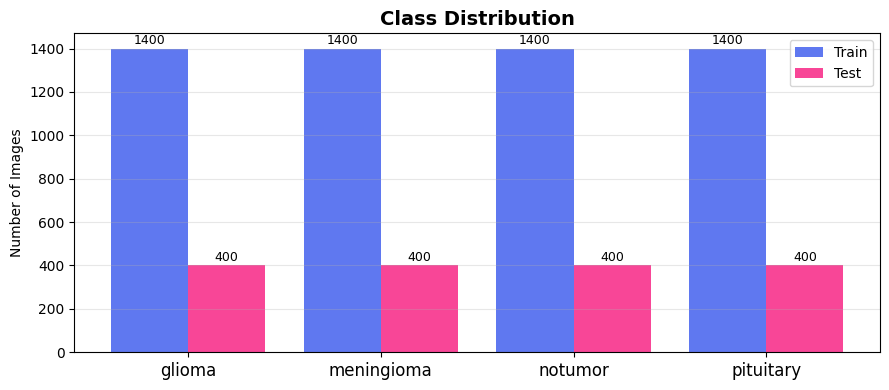

In [ ]:
# ── Class distribution bar chart ────────────────────────────────────────────
train_ds_raw = ImageFolder(root=cfg.TRAIN_DIR)
test_ds_raw  = ImageFolder(root=cfg.TEST_DIR)

train_counts = np.bincount([l for _, l in train_ds_raw.imgs])
test_counts  = np.bincount([l for _, l in test_ds_raw.imgs])

x = np.arange(len(CLASS_NAMES))
fig, ax = plt.subplots(figsize=(9, 4))
bars1 = ax.bar(x - 0.2, train_counts, width=0.4, label='Train', color='#4361ee', alpha=0.85)
bars2 = ax.bar(x + 0.2, test_counts,  width=0.4, label='Test',  color='#f72585', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, fontsize=12)
ax.set_ylabel('Number of Images'); ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.savefig(cfg.OUTPUT_DIR/'class_distribution.png', dpi=150, bbox_inches='tight'); plt.show()


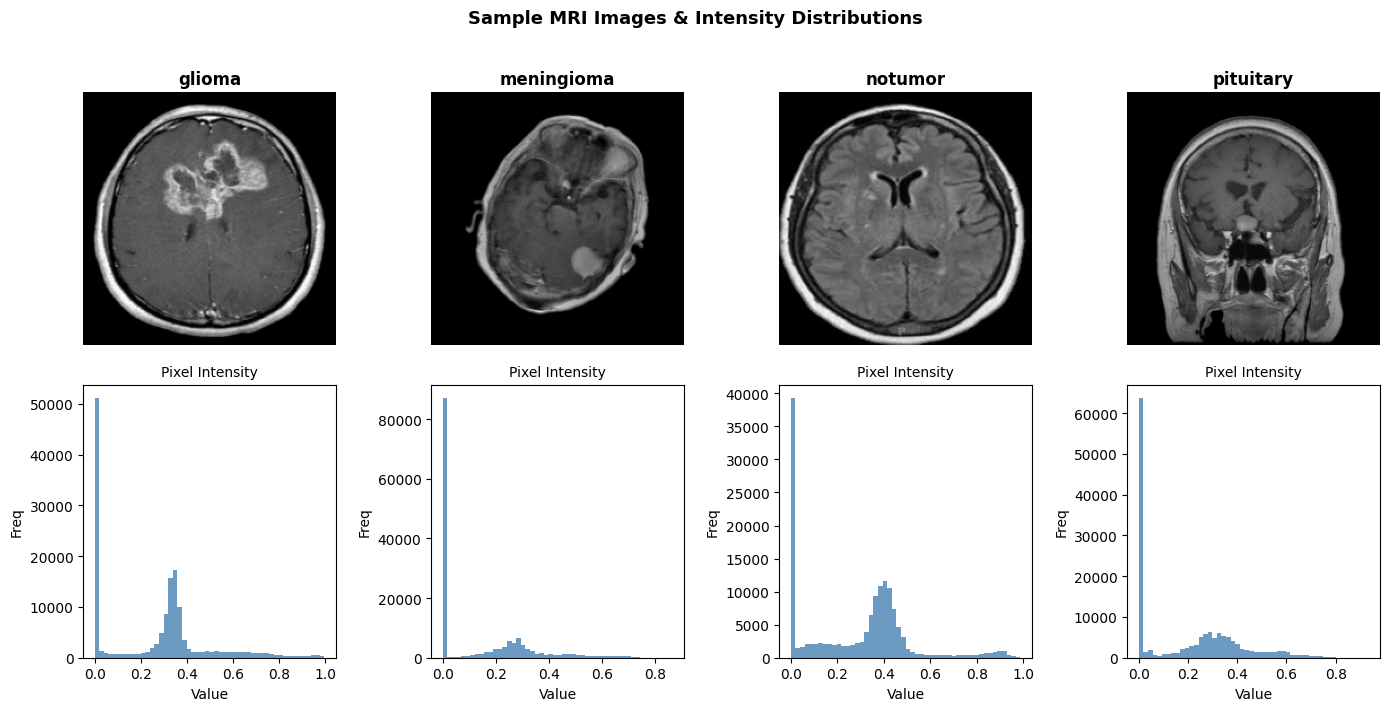

In [ ]:
# ── Sample images per class ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
inv_mean = np.array([0.485, 0.456, 0.406])
inv_std  = np.array([0.229, 0.224, 0.225])

# Scan batches until we have one image per class
shown = {}
for imgs_batch, labels_batch in test_loader:
    for img, lbl in zip(imgs_batch, labels_batch):
        lbl = lbl.item()
        if lbl not in shown:
            shown[lbl] = img
        if len(shown) == cfg.NUM_CLASSES:
            break
    if len(shown) == cfg.NUM_CLASSES:
        break

for col, (lbl, img) in enumerate(sorted(shown.items())):
    img_np = img.permute(1, 2, 0).numpy()
    img_np = (img_np * inv_std + inv_mean).clip(0, 1)

    axes[0, col].imshow(img_np)
    axes[0, col].set_title(CLASS_NAMES[lbl], fontsize=12, fontweight='bold')
    axes[0, col].axis('off')

    axes[1, col].hist(img_np.ravel(), bins=50, color='steelblue', alpha=0.8)
    axes[1, col].set_title('Pixel Intensity', fontsize=10)
    axes[1, col].set_xlabel('Value')
    axes[1, col].set_ylabel('Freq')

plt.suptitle('Sample MRI Images & Intensity Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 6. Model Definition — ResNet-50


In [ ]:
class BrainTumorResNet50(nn.Module):
    """
    ResNet-50 backbone + custom 2-layer classification head.

    Head architecture:
        AdaptiveAvgPool (built-in) → Dropout → FC(2048→512)
        → BatchNorm → ReLU → Dropout → FC(512→4)

    ResNet-50 children() layout (used in unfreeze_last_n_blocks):
      Index  Layer
      ─────  ─────────────────────────────
        0    conv1  (7×7 stem)
        1    bn1
        2    relu
        3    maxpool
        4    layer1  (3 residual blocks)
        5    layer2  (4 residual blocks)
        6    layer3  (6 residual blocks)
        7    layer4  (3 residual blocks)  ← most semantic
        8    avgpool
    children[4:] = [layer1, layer2, layer3, layer4, avgpool]
    With n=2: unfreezes layer4 + avgpool (the last 2 of that slice).
    """
    def __init__(self, num_classes=4, dropout=0.4, freeze_backbone=True):
        super().__init__()
        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

        # Keep all layers except the final FC
        self.features = nn.Sequential(*list(backbone.children())[:-1])

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout / 2),
            nn.Linear(512, num_classes),
        )

        # Kaiming init for the head
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

        if freeze_backbone:
            self.freeze_backbone()

    def freeze_backbone(self):
        for p in self.features.parameters():
            p.requires_grad = False

    def unfreeze_last_n_blocks(self, n: int):
        """Unfreeze the last n layers from children[4:] = [layer1..layer4, avgpool].
        With n=2 (default): unfreezes layer4 + avgpool.
        """
        children = list(self.features.children())
        # children[4:] excludes the early stem (conv1, bn1, relu, maxpool)
        for layer in children[4:][-n:]:
            for p in layer.parameters():
                p.requires_grad = True
        print(f'  Unfroze last {n} backbone block(s) ✅')

    def forward(self, x):
        x = self.features(x)       # [B, 2048, 1, 1]
        x = torch.flatten(x, 1)    # [B, 2048]
        return self.classifier(x)  # [B, 4]


# ── Instantiate & inspect ────────────────────────────────────────────────────
model = BrainTumorResNet50(
    num_classes=cfg.NUM_CLASSES,
    dropout=cfg.DROPOUT_RATE,
    freeze_backbone=True,
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}  ({100*trainable_params/total_params:.1f}%)')

dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
out   = model(dummy)
print(f'Output shape     : {out.shape}  ← should be [2, 4]')


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s]


Total params     : 24,560,196
Trainable params : 1,052,164  (4.3%)
Output shape     : torch.Size([2, 4])  ← should be [2, 4]


## 7. Training Loop


In [ ]:
# ── Helper: running average ──────────────────────────────────────────────────
class AverageMeter:
    def __init__(self): self.reset()
    def reset(self): self.val = self.avg = self.sum = self.count = 0.0
    def update(self, val, n=1):
        self.sum += val * n; self.count += n; self.avg = self.sum / self.count


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    loss_m = AverageMeter()
    correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)                          # ← single forward pass
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        preds    = logits.argmax(1)                   # ← reuse logits, no second forward
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        loss_m.update(loss.item(), labels.size(0))
    return loss_m.avg, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    loss_m = AverageMeter()
    correct = total = 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss_m.update(criterion(logits, labels).item(), labels.size(0))
        probs  = torch.softmax(logits, 1)
        preds  = probs.argmax(1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return loss_m.avg, correct/total, np.array(all_preds), np.array(all_labels), np.array(all_probs)


def build_optimizer(model):
    head_params     = list(model.classifier.parameters())
    backbone_params = [p for p in model.features.parameters() if p.requires_grad]
    return optim.AdamW(
        [{'params': head_params,     'lr': cfg.HEAD_LR},
         {'params': backbone_params, 'lr': cfg.LR}],
        weight_decay=cfg.WEIGHT_DECAY,
    )

print('Training utilities ready ✅')


Training utilities ready ✅


In [ ]:
# ── Main training loop ───────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = build_optimizer(model)
scheduler = CosineAnnealingLR(optimizer, T_max=cfg.T_MAX, eta_min=1e-6)

history  = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
best_acc = 0.0
best_wts = None

print('='*70)
print('                         TRAINING')
print('='*70)

for epoch in range(cfg.NUM_EPOCHS):
    t0 = time.time()

    # Phase transition: unfreeze backbone after warm-up
    if epoch == cfg.FREEZE_EPOCHS:
        model.unfreeze_last_n_blocks(cfg.UNFREEZE_LAST_LAYERS)
        optimizer = build_optimizer(model)
        scheduler = CosineAnnealingLR(optimizer,
                                      T_max=cfg.T_MAX - cfg.FREEZE_EPOCHS,
                                      eta_min=1e-6)
        print(f'[Epoch {epoch}] Fine-tuning phase activated.')

    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)

    # Validate on val_loader
    vl_loss, vl_acc, _, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step()

    for k, v in zip(history, [tr_loss, tr_acc, vl_loss, vl_acc]):
        history[k].append(v)

    if vl_acc > best_acc:
        best_acc = vl_acc
        best_wts = copy.deepcopy(model.state_dict())
        torch.save(best_wts, cfg.OUTPUT_DIR / 'best_model.pt')

    # FIX: get_last_lr() returns a list (one value per param group).
    # After the optimizer rebuild, log both head and backbone LRs for clarity.
    lrs = scheduler.get_last_lr()
    lr_str = f'LR head={lrs[0]:.1e}' + (f' bb={lrs[1]:.1e}' if len(lrs) > 1 else '')

    print(
        f'Ep [{epoch+1:02d}/{cfg.NUM_EPOCHS}]  '
        f'TrLoss {tr_loss:.4f}  TrAcc {tr_acc:.4f}  '
        f'VlLoss {vl_loss:.4f}  VlAcc {vl_acc:.4f}  '
        f'{lr_str}  '
        f'[{time.time()-t0:.0f}s]'
    )

print(f'\n🏆 Best Validation Accuracy: {best_acc:.4f}')
model.load_state_dict(best_wts)


                         TRAINING
Ep [01/30]  TrLoss 0.9436  TrAcc 0.7147  VlLoss 0.8085  VlAcc 0.7619  LR head=1.0e-03 bb=1.0e-04  [36s]
Ep [02/30]  TrLoss 0.7996  TrAcc 0.7725  VlLoss 0.7496  VlAcc 0.7976  LR head=9.9e-04 bb=9.9e-05  [38s]
Ep [03/30]  TrLoss 0.7341  TrAcc 0.8130  VlLoss 0.7192  VlAcc 0.8060  LR head=9.8e-04 bb=9.8e-05  [34s]
Ep [04/30]  TrLoss 0.7222  TrAcc 0.8122  VlLoss 0.7299  VlAcc 0.8226  LR head=9.6e-04 bb=9.6e-05  [35s]
Ep [05/30]  TrLoss 0.7047  TrAcc 0.8185  VlLoss 0.6842  VlAcc 0.8393  LR head=9.3e-04 bb=9.3e-05  [37s]
  Unfroze last 4 backbone block(s) ✅
[Epoch 5] Fine-tuning phase activated.
Ep [06/30]  TrLoss 0.6001  TrAcc 0.8859  VlLoss 0.5186  VlAcc 0.9226  LR head=1.0e-03 bb=1.0e-04  [50s]
Ep [07/30]  TrLoss 0.4977  TrAcc 0.9366  VlLoss 0.4507  VlAcc 0.9548  LR head=9.8e-04 bb=9.8e-05  [47s]
Ep [08/30]  TrLoss 0.4699  TrAcc 0.9496  VlLoss 0.4442  VlAcc 0.9607  LR head=9.6e-04 bb=9.7e-05  [48s]
Ep [09/30]  TrLoss 0.4465  TrAcc 0.9584  VlLoss 0.4318  Vl

<All keys matched successfully>

## 8. Training Curves


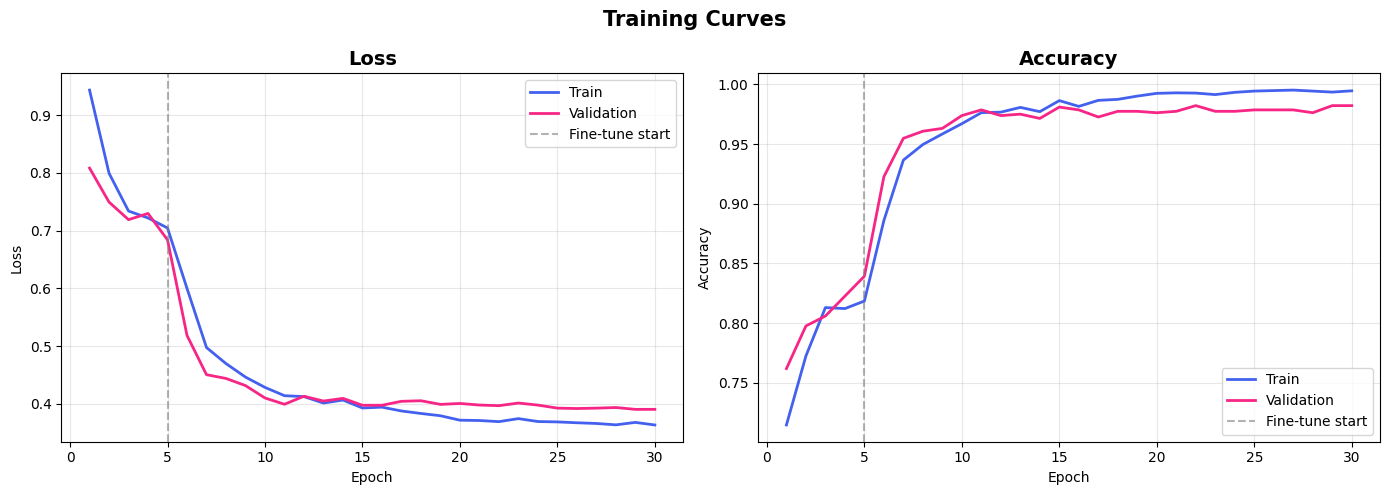

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], label='Train',      linewidth=2, color='#4361ee')
axes[0].plot(epochs, history['val_loss'],   label='Validation', linewidth=2, color='#f72585')
axes[0].axvline(cfg.FREEZE_EPOCHS, linestyle='--', color='gray', alpha=0.6, label='Fine-tune start')
axes[0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['train_acc'], label='Train',      linewidth=2, color='#4361ee')
axes[1].plot(epochs, history['val_acc'],   label='Validation', linewidth=2, color='#f72585')
axes[1].axvline(cfg.FREEZE_EPOCHS, linestyle='--', color='gray', alpha=0.6, label='Fine-tune start')
axes[1].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Training Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Evaluation — Metrics, Confusion Matrix & ROC Curves


In [ ]:
# ── Full metrics on the held-out test set ───────────────────────────────────
criterion_eval = nn.CrossEntropyLoss()
vl_loss, vl_acc, preds, labels, probs = evaluate(model, test_loader, criterion_eval)

print('='*65)
print('                    TEST SET RESULTS')
print('='*65)
print(f'Loss     : {vl_loss:.4f}')
print(f'Accuracy : {vl_acc:.4f}  ({vl_acc*100:.2f}%)')

print('\nPer-class Report:')
print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=4))

y_bin = label_binarize(labels, classes=list(range(cfg.NUM_CLASSES)))
macro_auc = roc_auc_score(y_bin, probs, multi_class='ovr', average='macro')
print(f'Macro-average AUC : {macro_auc:.4f}')


                    TEST SET RESULTS
Loss     : 0.2194
Accuracy : 0.9550  (95.50%)

Per-class Report:
              precision    recall  f1-score   support

      glioma     0.9970    0.8425    0.9133       400
  meningioma     0.9204    0.9825    0.9504       400
     notumor     0.9281    1.0000    0.9627       400
   pituitary     0.9851    0.9950    0.9900       400

    accuracy                         0.9550      1600
   macro avg     0.9577    0.9550    0.9541      1600
weighted avg     0.9577    0.9550    0.9541      1600

Macro-average AUC : 0.9854


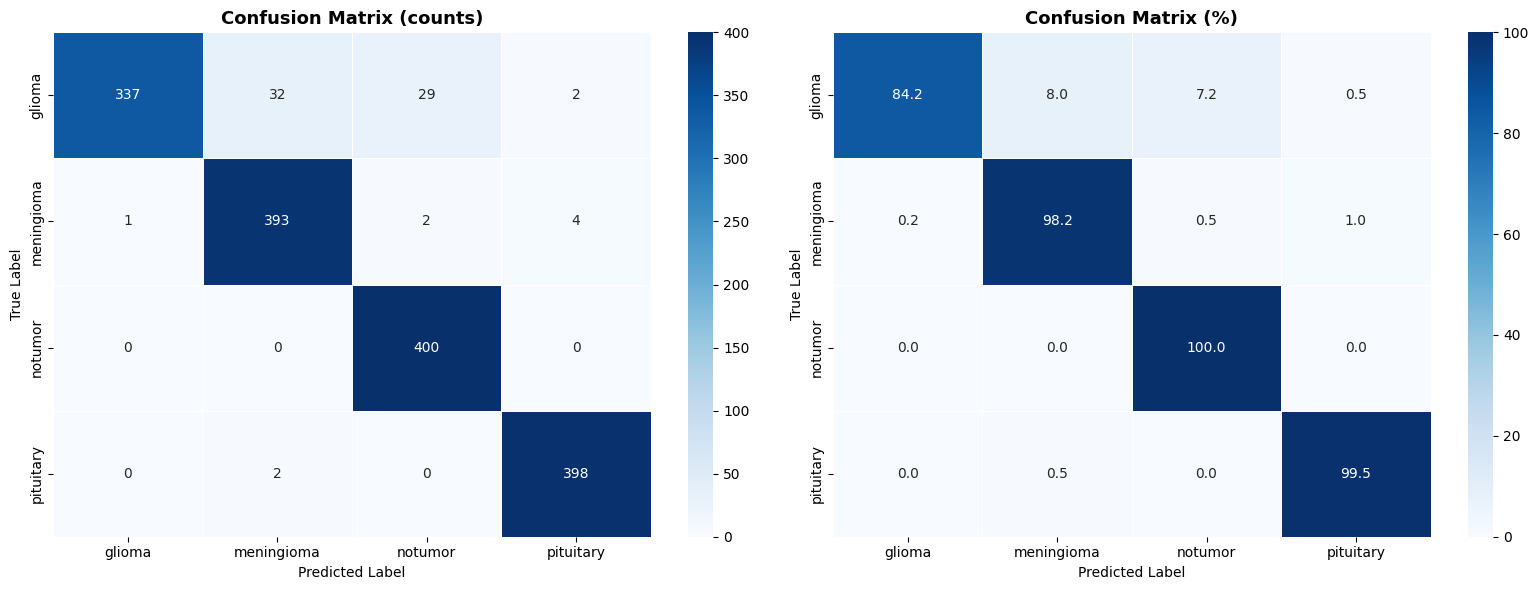

In [ ]:
# ── Confusion Matrix (normalised to row %) ──────────────────────────────────
# FIX: compute row-normalised percentages and use them for plotting.
# The original code had cm_pct commented out but kept the '(%)' title,
# causing a mismatch between the plot values and the title.
cm     = confusion_matrix(labels, preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: raw counts
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=axes[0],
)
axes[0].set_title('Confusion Matrix (counts)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')

# Right: row-normalised percentages
sns.heatmap(
    cm_pct, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=axes[1], vmin=0, vmax=100,
)
axes[1].set_title('Confusion Matrix (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


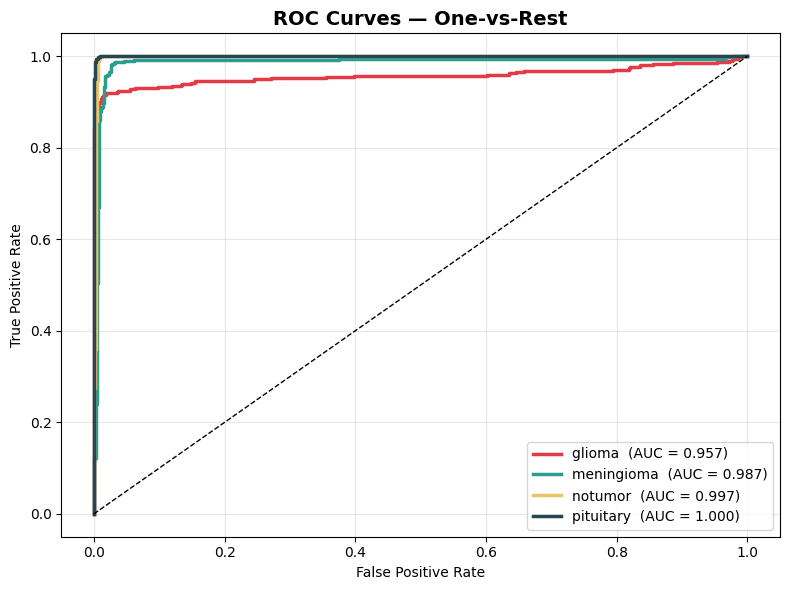

In [ ]:
# ── ROC Curves ───────────────────────────────────────────────────────────────
colors = ['#e63946', '#2a9d8f', '#e9c46a', '#264653']
fig, ax = plt.subplots(figsize=(8, 6))

for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name}  (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1],'k--', linewidth=1)
ax.set_title('ROC Curves — One-vs-Rest', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Grad-CAM Explainability

Grad-CAM highlights the MRI regions that drove the model's prediction — essential for medical AI transparency.


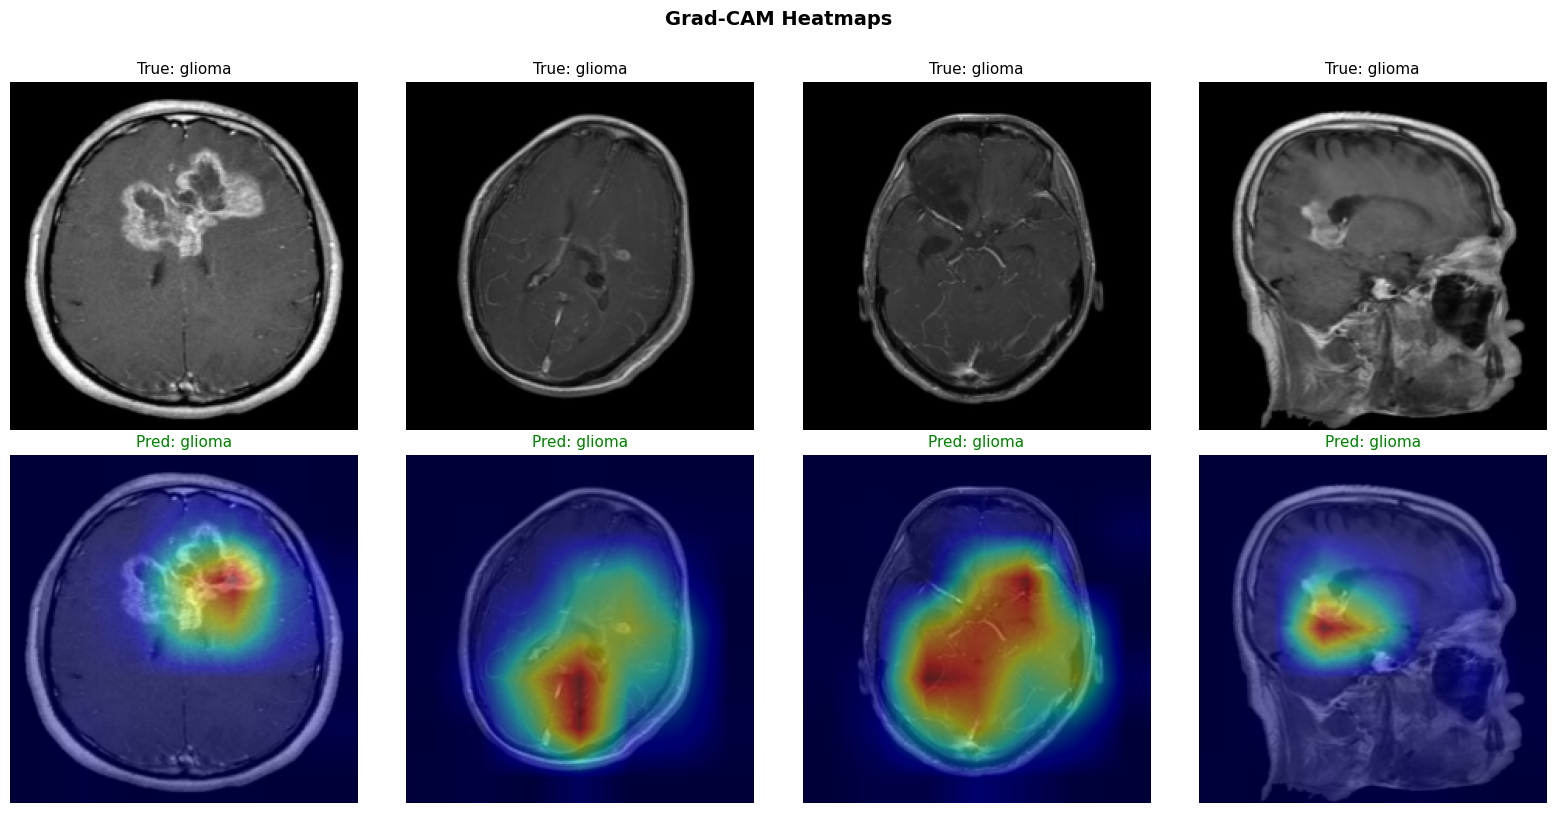

In [ ]:
class GradCAM:
    """
    Hooks into ResNet-50's final residual block (layer4[-1]).
    Returns a spatial heatmap in [0, 1] for a given class index.

    FIX: The original used register_full_backward_hook on the module, which
    captures input gradients — not the output gradients needed for Grad-CAM.
    We now use a tensor-level hook (register_hook) on the activation tensor
    itself, which captures d(loss)/d(activation) correctly.
    """
    def __init__(self, model):
        self.model       = model
        self.gradients   = None
        self.activations = None
        self._hook_handle = None

        # Forward hook: capture the activation tensor of layer4's last block
        target = list(model.features.children())[7][-1]  # layer4[-1]
        target.register_forward_hook(self._forward_hook)

    def _forward_hook(self, module, input, output):
        # Save activations and attach a tensor-level gradient hook
        self.activations = output.detach()
        # Remove previous gradient hook if any
        if self._hook_handle is not None:
            self._hook_handle.remove()
        # register_hook on the output tensor captures d(loss)/d(output) — correct for Grad-CAM
        self._hook_handle = output.register_hook(self._gradient_hook)

    def _gradient_hook(self, grad):
        self.gradients = grad.detach()

    def generate(self, img_tensor, class_idx=None):
        self.model.eval()
        t = img_tensor.unsqueeze(0).to(DEVICE)
        t.requires_grad_(False)  # gradients flow through the graph, not the input

        # Enable grad for backward pass
        with torch.enable_grad():
            logits = self.model(t)
            if class_idx is None:
                class_idx = logits.argmax(1).item()
            self.model.zero_grad()
            logits[0, class_idx].backward()

        # Global average pool the gradients → per-channel weights
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # [1, C, 1, 1]
        cam = torch.relu((weights * self.activations).sum(1)).squeeze()  # [H, W]
        cam -= cam.min()
        cam /= cam.max() + 1e-8
        return cam.cpu().numpy(), class_idx


gcam     = GradCAM(model)
n        = 4
inv_mean = np.array([0.485, 0.456, 0.406])
inv_std  = np.array([0.229, 0.224, 0.225])

imgs_b, lbls_b = next(iter(test_loader))
imgs_b, lbls_b = imgs_b[:n], lbls_b[:n]

fig, axes = plt.subplots(2, n, figsize=(4*n, 8))

for i in range(n):
    img_t      = imgs_b[i]
    true_lbl   = CLASS_NAMES[lbls_b[i].item()]
    cam, p_idx = gcam.generate(img_t)
    pred_lbl   = CLASS_NAMES[p_idx]

    img_np = (img_t.permute(1,2,0).numpy() * inv_std + inv_mean).clip(0,1)
    cam_r  = np.array(
        Image.fromarray((cam*255).astype(np.uint8))
             .resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE), Image.BILINEAR)
    ) / 255.0

    axes[0,i].imshow(img_np); axes[0,i].set_title(f'True: {true_lbl}', fontsize=11); axes[0,i].axis('off')
    axes[1,i].imshow(img_np)
    axes[1,i].imshow(cam_r, cmap='jet', alpha=0.45)
    color = 'green' if pred_lbl == true_lbl else 'red'
    axes[1,i].set_title(f'Pred: {pred_lbl}', fontsize=11, color=color)
    axes[1,i].axis('off')

plt.suptitle('Grad-CAM Heatmaps', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / 'gradcam.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Single-Image Inference


In [ ]:
def predict_single_image(model, image_path, class_names):
    """Run inference on one MRI image with a confidence bar display.

    FIX: The original loaded the raw image directly into eval_tf, skipping
    skull_strip. This caused a train/test preprocessing mismatch because the
    model was trained exclusively on skull-stripped images. We now apply
    skull_strip first to match the training pipeline exactly.
    """
    _, eval_tf = get_transforms()

    raw_img = Image.open(image_path).convert('RGB')

    # FIX: skull_strip before transforms — matches training pipeline
    stripped = skull_strip(raw_img)
    tensor   = eval_tf(stripped).unsqueeze(0).to(DEVICE)

    model.eval()
    probs = torch.softmax(model(tensor), 1).squeeze().detach().cpu().numpy()

    pred = class_names[np.argmax(probs)]

    # ── matplotlib bar chart ─────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(raw_img); axes[0].axis('off')
    axes[0].set_title(f'Prediction: {pred.upper()}', fontsize=13, fontweight='bold',
                      color='#2a9d8f')
    colors = ['#e63946' if n == pred else '#adb5bd' for n in class_names]
    bars = axes[1].barh(class_names, probs * 100, color=colors, height=0.5)
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_title('Class Probabilities', fontsize=12)
    axes[1].set_xlim(0, 100)
    for bar, p in zip(bars, probs):
        axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                     f'{p*100:.1f}%', va='center', fontsize=10)
    plt.tight_layout(); plt.show()
    return pred, probs


# ── Demo: pick a sample from the raw test folder ─────────────────────────────
test_ds_raw = ImageFolder(root=cfg.TEST_DIR)
sample_path, sample_label = test_ds_raw.imgs[50]
print(f'Running inference on: {sample_path}')
print(f'True class          : {CLASS_NAMES[sample_label]}')
pred, probs = predict_single_image(model, sample_path, CLASS_NAMES)


NameError: name 'ImageFolder' is not defined

## 12. Save & Download Model


In [ ]:
import json

# ── Save full checkpoint ─────────────────────────────────────────────────────
# FIX: include optimizer_state_dict so training can be resumed from this point.
checkpoint = {
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),   # ← added for resumable training
    'class_to_idx'        : class_to_idx,
    'class_names'         : CLASS_NAMES,
    'best_val_acc'        : best_acc,
    'config': {
        'num_classes'  : cfg.NUM_CLASSES,
        'image_size'   : cfg.IMAGE_SIZE,
        'dropout_rate' : cfg.DROPOUT_RATE,
        'num_epochs'   : cfg.NUM_EPOCHS,
    }
}
ckpt_path = cfg.OUTPUT_DIR / 'brain_tumor_resnet50_checkpoint.pt'
torch.save(checkpoint, ckpt_path)
print(f'Checkpoint saved: {ckpt_path}')

# ── Save training history as JSON ────────────────────────────────────────────
hist_path = cfg.OUTPUT_DIR / 'training_history.json'
with open(hist_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f'History saved   : {hist_path}')

# ── List all outputs ─────────────────────────────────────────────────────────
print('\nOutputs directory:')
for p in sorted(cfg.OUTPUT_DIR.iterdir()):
    print(f'  {p.name:40s}  {p.stat().st_size/1e6:.2f} MB')


Checkpoint saved: outputs/brain_tumor_resnet50_checkpoint.pt
History saved   : outputs/training_history.json

Outputs directory:
  best_model.pt                             98.57 MB
  brain_tumor_resnet50_checkpoint.pt        293.38 MB
  class_distribution.png                    0.04 MB
  confusion_matrix.png                      0.08 MB
  gradcam.png                               1.14 MB
  roc_curves.png                            0.07 MB
  training_curves.png                       0.11 MB
  training_history.json                     0.00 MB


In [ ]:
# ── Zip & download all outputs ───────────────────────────────────────────────
import shutil
from google.colab import files

zip_path = '/content/brain_tumor_outputs'
shutil.make_archive(zip_path, 'zip', cfg.OUTPUT_DIR)
files.download(zip_path + '.zip')
print('Download started ✅')


NameError: name 'cfg' is not defined

---
## 📌 How to Load the Saved Model Later

```python
checkpoint = torch.load('brain_tumor_resnet50_checkpoint.pt', map_location='cpu')

model = BrainTumorResNet50(num_classes=4, dropout=0.4, freeze_backbone=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print('Classes :', checkpoint['class_names'])
print('Val Acc :', checkpoint['best_val_acc'])

# To resume training:
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
```

---
## 💡 Ideas to Improve Further

| Technique | Expected Gain |
|---|---|
| Unfreeze all layers (`UNFREEZE_LAST_LAYERS=4`) | +0.5–1% acc |
| Test-Time Augmentation (TTA) | +0.5% acc, better calibration |
| MixUp / CutMix augmentation | Smoother decision boundaries |
| EfficientNet-B4 / ConvNeXt backbone swap | Potential +2–3% |
| Ensemble 3 models | More robust predictions |
| Focal Loss (for class imbalance) | Better minority class recall |
